In [1]:
%load_ext autoreload
%autoreload 2
# !pip install leafmap datasets git+https://github.com/aliFrancis/SEnSeIv2.git@refactor-inference
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import pickle
import os
import sys
import glob
from skimage import transform
import matplotlib.pyplot as plt
import numpy as np
import re
from pathlib import Path
import urllib.request
from datetime import datetime
import copy
from skimage import io as skio
from skimage import util as skutil
src_path = os.path.join(os.getcwd(), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)
from clustring_lr_gapfilling import SpatioTemporalGapFilling
from dtw_seg import DTWSegmentation
from pixel_weighting_Gap_filling import PixelWeightingGapFilling 
from ssrf_gap_filling import SSRF_GapFilling
from rasterio.transform import from_origin
import os
import numpy as np
import rasterio
from rasterio.mask import mask

In [2]:
def extract_bitmask(value, bit, num_bits=1):
    """Extract specific bits from an integer value."""
    return (value.astype(np.uint16) >> bit) & ((1 << num_bits) - 1)

def generate_cloud_mask(input_tif, output_tif):
    """Generate a cloud mask from the MODIS state_1km dataset."""
    with rasterio.open(input_tif) as src:
        state_data = src.read(1).astype(np.uint16)  # Ensure data is integer
        profile = src.profile

        # Extract cloud state bits (Bits 0-1)
        cloud_state = extract_bitmask(state_data, 0, 2)  # Extract bits 0-1
        internal_cloud = extract_bitmask(state_data, 10, 1)  # Extract bit 10
        adjacent_to_cloud = extract_bitmask(state_data, 13, 1)  # Extract bit 13

        # Cloudy pixels are where cloud state is 1 or 2, or internal cloud is set
        cloud_mask = (cloud_state == 1) | (cloud_state == 2) | (internal_cloud == 1) | (adjacent_to_cloud == 1)
        
        # Convert boolean mask to integer (1 for cloudy, 0 for clear)
        cloud_mask = cloud_mask.astype(np.uint8)

        # Update profile for the output file
        profile.update(dtype=rasterio.uint8, count=1, compress='lzw')

        # Save mask to a new GeoTIFF file
        with rasterio.open(output_tif, 'w', **profile) as dst:
            dst.write(cloud_mask, 1)

# Process all state_1km TIFFs in a folder
def process_folder(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    for file in os.listdir(input_folder):
        if file.endswith(".tif"):
            input_path = os.path.join(input_folder, file)
            output_path = os.path.join(output_folder, f"cloud_mask_{file}")
            generate_cloud_mask(input_path, output_path)
            print(f"Processed: {file} -> {output_path}")

In [3]:
# # Example usage
# input_folder = "../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_state/"
# output_folder = "../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_masks/"
# process_folder(input_folder, output_folder)

In [4]:
def find_tif_files(folder_path):
    # Use glob to recursively find all .tif files in the specified folder and subfolders
    tif_files = glob.glob(os.path.join(folder_path, '**', '*.tif'), recursive=True)
    return tif_files

def brighten(band):
    alpha=0.13
    beta=0
    return np.clip(alpha*band+beta, 0,255)


def read_tif_band(tif_path, band_index):
   
    with rasterio.open(tif_path) as dataset:
        # Read the specified band (band_index is 1-based)
        band = dataset.read(band_index)
    return band 

def plot_rgb_with_cloud_mask(data):
    for item in data:
        # Extract RGB bands and cloud mask
        B1 = item['B3']
        B4 = item['B2']
        B3 = item['B1']
        cloud_mask = item['cloud_mask']
        date = item['date']

        # Stack the RGB bands to create an RGB image
        rgb_image = np.stack([B1, B4, B3], axis=-1)

        # Plot the RGB image and the cloud mask overlay
        plt.figure(figsize=(15, 15))

        # Plot the RGB image
        plt.subplot(1, 2, 1)
        plt.imshow(rgb_image)
        plt.title('RGB Image')

        # Plot the cloud mask overlay
        plt.subplot(1, 2, 2)
        plt.imshow(rgb_image)
        plt.imshow(cloud_mask, cmap='jet', alpha=0.5)  # Overlay the cloud mask with transparency
        plt.title(f'RGB Image with Cloud Mask Overlay\nDate: {date}')
        

        plt.show()


In [5]:
def save_multi_band(bands, filename, metadata, transform, crs):
    count = bands.shape[0]
    with rasterio.open(
        filename,
        'w',
        driver='GTiff',
        height=bands.shape[1],
        width=bands.shape[2],
        count=count,
        dtype=bands.dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        for i in range(count):
            dst.write(bands[i], i + 1)

# Define a function to read a TIFF file and extract metadata
def read_tif_file(tif_file):
    with rasterio.open(tif_file) as src:
        metadata = src.profile
        bands = src.read()
    return bands, metadata

def read_modis_files(masks_dir, bands_dir):
    """Read MODIS bands and cloud masks for each date and return as a sorted list of dictionaries."""
    data_list = []

    # Get all mask and band files
    mask_files = [f for f in os.listdir(masks_dir) if f.endswith('.tif')]
    band_files = [f for f in os.listdir(bands_dir) if f.endswith('.tif')]

    # Create a dictionary mapping dates to mask files
    mask_dict = {}
    for file in mask_files:
        date_part = file.split('_')[5:8][0]+"-"+file.split('_')[5:8][1]+"-"+file.split('_')[5:8][2].split(".")[0]  # Extract date part (e.g., '2023-01-01')
        mask_dict[date_part] = os.path.join(masks_dir, file)

    # Process each band file and match it with the mask
    for file in band_files:
        date_part = file.split('_')[2:5][0]+"-"+file.split('_')[2:5][1]+"-"+file.split('_')[2:5][2].split(".")[0]  # Extract date part (e.g., '2023-01-01')
        date = datetime.strptime(date_part, '%Y-%m-%d')

        data_entry = {
            'date': date,
            'is_cloudy': False,
            'cloud_mask': None
        }

        # Read the cloud mask if available for the date
        if date_part in mask_dict:
            mask_file = mask_dict[date_part]
            with rasterio.open(mask_file) as src:
                cloud_mask = src.read(1)
                data_entry['cloud_mask'] = cloud_mask
                data_entry['is_cloudy'] = np.max(cloud_mask) == 1  # Check if there's any cloud (1)

        # Read the bands
        with rasterio.open(os.path.join(bands_dir, file)) as src:
            for band_index in range(1, src.count + 1):
                band_name = f'B{band_index}'
                data_entry[band_name] = src.read(band_index).astype(np.float32)

        data_list.append(data_entry)

    # Sort the list by the 'date' field
    data_list_sorted = sorted(data_list, key=lambda x: x['date'])

    return data_list_sorted

In [6]:
masks_dir = '../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_masks/'
bands_dir = '../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_Agdal/'
data_dict = read_modis_files(masks_dir, bands_dir)

In [7]:
data_dict = sorted(data_dict, key=lambda x: x['date'])

In [18]:
len(data_dict[2]["B2"])

8

In [8]:
# plot_rgb_with_cloud_mask(data_dict)

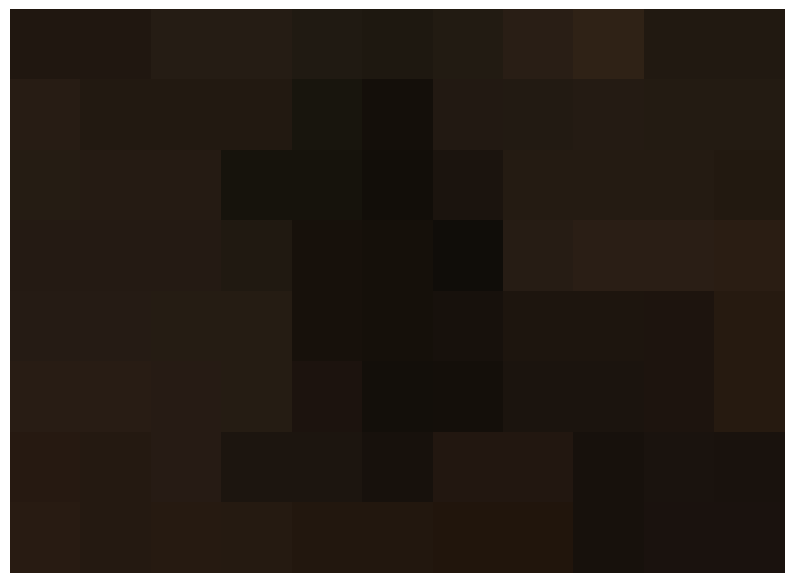

In [9]:
rgb1=np.stack([data_dict[11]["B1"], data_dict[11]["B4"], data_dict[11]["B3"]], axis=-1)
plt.figure(figsize=(10, 10))  # Adjust the figsize to make the image larger
plt.imshow(rgb1)
plt.axis('off')  # Hide the axes
plt.grid(False)  # Hide the grid linesQ
plt.show()

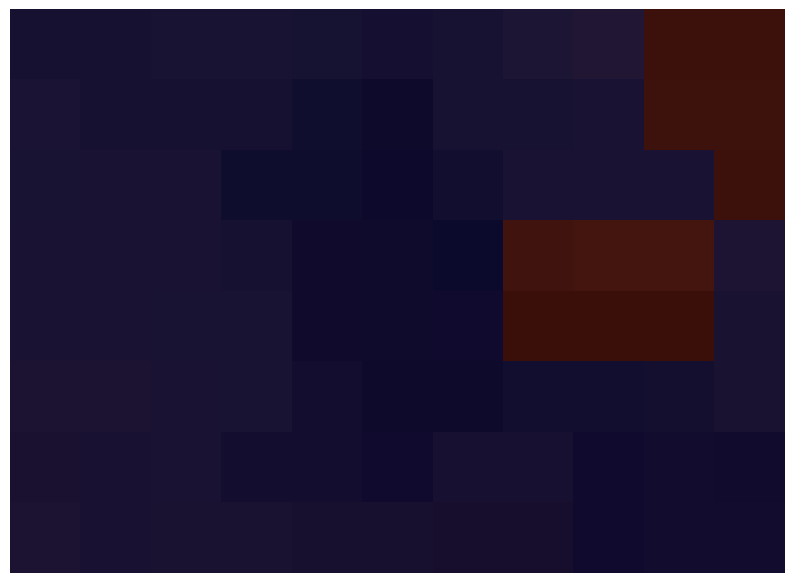

In [10]:
rgb1=np.stack([data_dict[11]["B1"], data_dict[11]["B4"], data_dict[11]["B3"]], axis=-1)
plt.figure(figsize=(10, 10))  # Adjust the figsize to make the image larger
plt.imshow(rgb1)
plt.imshow(data_dict[11]["cloud_mask"], cmap='jet', alpha=0.3)
plt.axis('off')  # Hide the axes
plt.grid(False)  # Hide the grid lines
plt.show()

In [134]:
# band_B2_dict = {}
# band_B3_dict = {}
# band_B4_dict = {}
# cloud_mask_dict = {}
# data_dict_copy =copy.deepcopy(data_dict)
# for item in data_dict_copy:
#     date = datetime.strptime(item['date'], '%Y-%m-%d')
    
#     # Create masked arrays where cloud_mask is 1
#     B2_masked = np.where(item['cloud_mask'], np.nan, item['B2'])
#     B3_masked = np.where(item['cloud_mask'], np.nan, item['B3'])
#     B4_masked = np.where(item['cloud_mask'], np.nan, item['B4'])

#     # Store masked arrays in respective dictionaries
#     band_B2_dict[date] = B2_masked
#     band_B3_dict[date] = B3_masked
#     band_B4_dict[date] = B4_masked
#     cloud_mask_dict[date] = item['cloud_mask']
# bands_dict_gap={
#     "B2":band_B2_dict,
#     "B3":band_B3_dict,
#     "B4":band_B4_dict,
# }

In [66]:
# band_B2_dict = {}
# band_B3_dict = {}
# band_B4_dict = {}
# cloud_mask_dict = {}
# for item in data_dict:
#     date = datetime.strptime(item['date'], '%Y-%m-%d')
    
#     # Store masked arrays in respective dictionaries
#     band_B2_dict[date] = item["B2"]
#     band_B3_dict[date] = item["B3"]
#     band_B4_dict[date] = item["B4"]
# bands_dict_ground_truth={
#     "B2":band_B2_dict,
#     "B3":band_B3_dict,
#     "B4":band_B4_dict,
# }

In [14]:
len(data_dict)

1081

In [19]:
import numpy as np
import copy
from datetime import datetime

# Initialize dictionaries for each band and cloud masks
bands_dict = {band: {} for band in ['B1', 'B2', 'B3', 'B4', 'B5', 'B6',"B7"]}
cloud_mask_dict = {}

# Deep copy the original data to avoid modifying it
data_dict_copy = copy.deepcopy(data_dict)

# Sort the data by date
data_dict_copy = sorted(data_dict_copy, key=lambda x: x['date'])

# Iterate over the sorted data
for item in data_dict_copy:
    # Extract the date from the 'date' field
    date = item['date']

    # Apply cloud mask to each band: set cloudy areas to NaN
    for band in ['B1', 'B2', 'B3', 'B4', 'B5', 'B6',"B7"]:
        if band in item:
            masked_array = np.where(item['cloud_mask'], np.nan, item[band])
            bands_dict[band][date] = masked_array

    # Store the cloud mask for the date
    cloud_mask_dict[date] = item['cloud_mask']

# Combine the bands and cloud masks into a single dictionary
bands_dict_gap = {**bands_dict, "cloud_mask": cloud_mask_dict}

# Example: Print a summary to verify the contents
print("Sorted Data:")
for date, b2_data in bands_dict_gap["B2"].items():
    print(f"Date: {date}")


Sorted Data:
Date: 2022-01-01 00:00:00
Date: 2022-01-02 00:00:00
Date: 2022-01-03 00:00:00
Date: 2022-01-04 00:00:00
Date: 2022-01-05 00:00:00
Date: 2022-01-06 00:00:00
Date: 2022-01-07 00:00:00
Date: 2022-01-08 00:00:00
Date: 2022-01-09 00:00:00
Date: 2022-01-10 00:00:00
Date: 2022-01-11 00:00:00
Date: 2022-01-12 00:00:00
Date: 2022-01-13 00:00:00
Date: 2022-01-14 00:00:00
Date: 2022-01-15 00:00:00
Date: 2022-01-16 00:00:00
Date: 2022-01-17 00:00:00
Date: 2022-01-18 00:00:00
Date: 2022-01-19 00:00:00
Date: 2022-01-20 00:00:00
Date: 2022-01-21 00:00:00
Date: 2022-01-22 00:00:00
Date: 2022-01-23 00:00:00
Date: 2022-01-24 00:00:00
Date: 2022-01-25 00:00:00
Date: 2022-01-26 00:00:00
Date: 2022-01-27 00:00:00
Date: 2022-01-28 00:00:00
Date: 2022-01-29 00:00:00
Date: 2022-01-30 00:00:00
Date: 2022-01-31 00:00:00
Date: 2022-02-01 00:00:00
Date: 2022-02-02 00:00:00
Date: 2022-02-03 00:00:00
Date: 2022-02-04 00:00:00
Date: 2022-02-05 00:00:00
Date: 2022-02-06 00:00:00
Date: 2022-02-07 00:00:00

## **Spatio-Temporal**

### **CLR Method**

In [14]:
gapFilling=SpatioTemporalGapFilling()
clr_results={}
for band in bands_dict_gap.keys():
    if band !="cloud_mask":
        filled_result = gapFilling.reconstruct_filled_stack_images(bands_dict_gap[band], 100)
        clr_results[band]=filled_result

overlap_thesh : 100
The function took 1.3793635368347168 seconds to execute.
overlap_thesh : 100
The function took 1.373882532119751 seconds to execute.
overlap_thesh : 100
The function took 1.4386537075042725 seconds to execute.
overlap_thesh : 100
The function took 1.3740909099578857 seconds to execute.
overlap_thesh : 100
The function took 1.3770642280578613 seconds to execute.
overlap_thesh : 100
The function took 1.4416399002075195 seconds to execute.
overlap_thesh : 100
The function took 1.3719842433929443 seconds to execute.


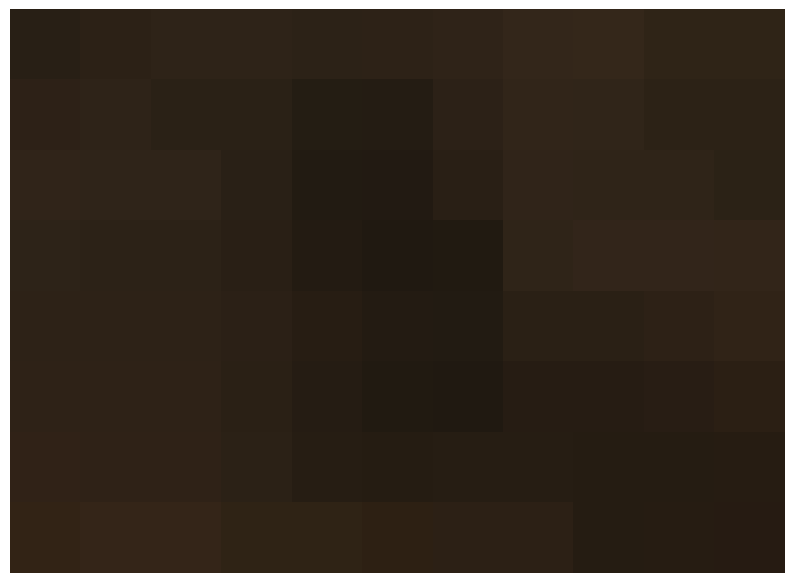

In [15]:
target_image=data_dict[1]["date"]
rgb_clr=np.stack([clr_results["B1"][target_image], clr_results["B4"][target_image], clr_results["B3"][target_image]], axis=-1)
plt.figure(figsize=(10, 10))  # Adjust the figsize to make the image larger
plt.imshow(rgb_clr)
plt.axis('off')  # Hide the axes
plt.grid(False)  # Hide the grid lines
plt.show()

In [18]:
import os
import rasterio
import numpy as np
from datetime import datetime

def save_dict_as_multiband_tifs(data_dict, reference_tif, output_dir="./output/s2"):
    
    # Create the output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Extract metadata from the first reference TIFF
    with rasterio.open(reference_tif) as src:
        metadata = src.meta.copy()
        transform = src.transform
        crs = src.crs

    # Collect all unique dates from the data dictionary
    unique_dates = set(date for band_dict in data_dict.values() for date in band_dict.keys())

    # Iterate over each unique date
    for date in sorted(unique_dates):
        date_str = date.strftime('%Y%m%d')
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f"modis_GP_{date_str}.tif")

        # Gather the arrays for all bands for the current date
        band_arrays = []
        for band in ['B1', 'B2', 'B3', 'B4', 'B5', 'B6',"B7"]:
            if date in data_dict[band]:
                band_arrays.append(data_dict[band][date])
            else:
                print("nan")
                # If a band is missing for a given date, fill with NaNs
                reference_shape = list(data_dict.values())[0][date].shape
                band_arrays.append(np.full(reference_shape, np.nan, dtype=np.float32))

        # Convert the list of arrays to a 3D array (Bands, Height, Width)
        stacked_array = np.stack(band_arrays, axis=0)

        # Update metadata for multi-band TIFF
        metadata.update({
            "count": len(band_arrays),  # Number of bands
            "height": stacked_array.shape[1],
            "width": stacked_array.shape[2],
            "transform": transform,
            "crs": crs,
            "dtype": str(stacked_array.dtype)
        })

        # Save the multi-band TIFF
        with rasterio.open(output_path, 'w', **metadata) as dst:
            for i in range(stacked_array.shape[0]):
                dst.write(stacked_array[i], i + 1)  # Write each band

        print(f"Saved {output_path}")

In [19]:
save_dict_as_multiband_tifs(clr_results,"../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_Agdal/MODIS_Agdal_2022_01_05.tif", output_dir="../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/")

Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220101.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220102.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220103.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220104.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220105.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220106.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220107.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220108.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/modis_gf/modis_GP_20220109.tif
Saved ../../lustre/rspa-kyyj3mesntk/users/said.grich/Rs_data/Robot_data/m

In [109]:
import pandas as pd
df=pd.DataFrame(data_dict)
df=df.drop(columns=["cloud_mask","B1","B2","B3","B4","B5","B6","B7"])

In [122]:
df.to_csv("modis_state.csv")

In [125]:
df['date'] = df['date'].astype(str)

date_list = df['date'].tolist()

In [13]:
import os
import pandas as pd
import rasterio
from shapely.geometry import Point

# Define the point of interest
point = Point(-7.679777777777778, 31.66338888888889)

# Directory path containing the .tif files
tif_directory = './data/input/elghaba/modis/masks/'

# Initialize an empty list to store results
data = []

# Loop through each .tif file in the directory
for filename in sorted(os.listdir(tif_directory)):
    if filename.endswith('.tif'):
        file_path = os.path.join(tif_directory, filename)
        
        # Extract the date from the filename
        date = filename.split('_')[-1].replace('.tif', '')
        
        # Open the .tif file and extract the value at the point
        with rasterio.open(file_path) as src:
            # Convert the point to the raster's coordinate system
            x, y = point.x, point.y
            row, col = src.index(x, y)
            
            # Read the value at the point and determine if it's cloudy or not
            value = src.read(1)[row, col]
            is_cloudy = value > 0  # Assuming non-zero values indicate cloud presence
            
            # Append the date and cloud status to the data list
            data.append([date, is_cloudy])

# Create a DataFrame from the data list
df = pd.DataFrame(data, columns=['date', 'is_cloudy'])

df.to_csv("moids_status_2.csv")

In [12]:
cloudy_count = df['is_cloudy'].value_counts()
cloudy_count

is_cloudy
False    270
True      90
Name: count, dtype: int64